In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster    import KMeans
from sklearn.metrics    import silhouette_score

file = r"C:\Users\Highlightning\Documents\Ciencia de Datos\Proyectos\Clustering (Customer Segmentation & Persona Profiling)\.gitignore\data\processed\rfm_scaled.csv"
rfm_scaled = pd.read_csv(file)

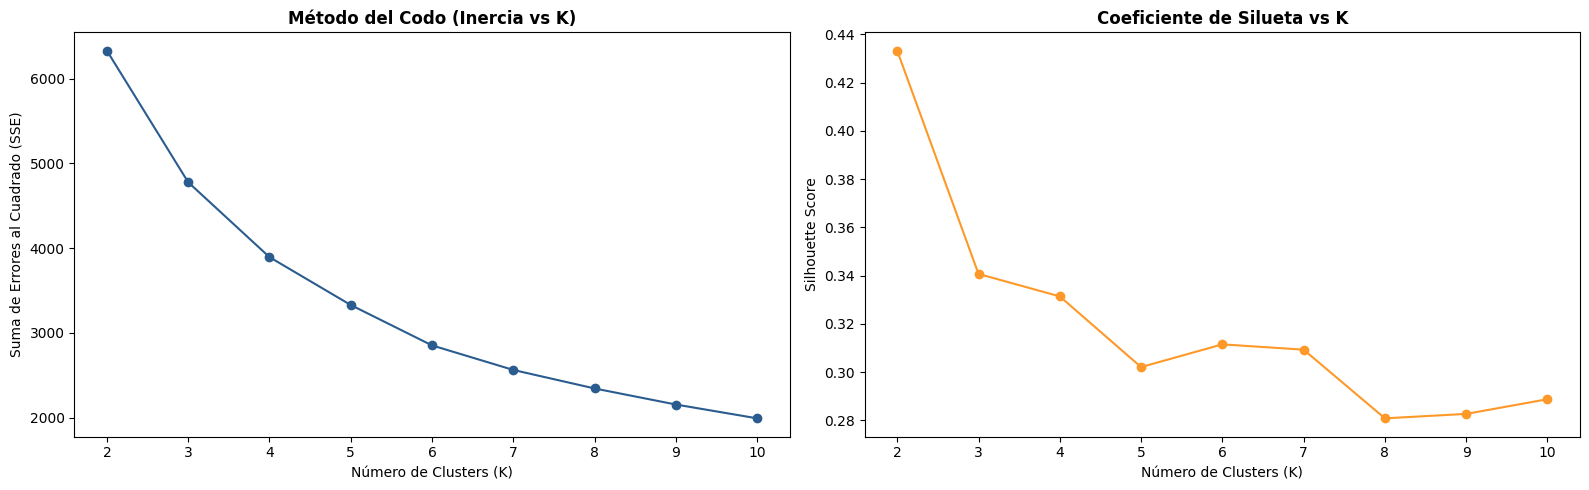

In [3]:
X = rfm_scaled.drop(columns=["CustomerID"])
sse = {}    # Sum of Squared Errors (.inertia_)
silhouette_coef = {}

k_range = range(2,11) # 2 to 10

for k in k_range:
    k_means = KMeans(n_clusters=k, random_state=42, n_init=10)
    k_means.fit(X)
    sse[k] = k_means.inertia_
    score = silhouette_score(X=X, labels=k_means.labels_)
    silhouette_coef[k] = score

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(16,5))
# Gráfico: Método de Codo
ax1.plot(list(sse.keys()), list(sse.values()), marker="o", color="#2b5c8f")
ax1.set_title("Método del Codo (Inercia vs K)", fontweight="bold")
ax1.set_xlabel("Número de Clusters (K)")
ax1.set_ylabel("Suma de Errores al Cuadrado (SSE)")

#Gráfico: Coeficientes de Silueta
ax2.plot(list(silhouette_coef.keys()), list(silhouette_coef.values()), marker="o", color="#fe9929")
ax2.set_title("Coeficiente de Silueta vs K", fontweight="bold")
ax2.set_xlabel("Número de Clusters (K)")
ax2.set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

<h3>📊 Análisis de los Resultados</h3>

**1. Método del Codo (Elbow Method):**
* Se observa un punto de quiebre notable en $K = 3$ y $K = 4$.

* A partir de $K = 4$, la reducción de la inercia (SSE) se vuelve más gradual y lineal, lo que indica retornos decrecientes al agregar más grupos.

**2. Coeficiente de Silueta (Silhouette Score):**
* $K = 2$ muestra el valor de silueta más alto ($\approx 0.43$). Sin embargo, desde una perspectiva de negocio/marketing, agrupar a toda la base en solo 2 segmentos suele ser demasiado simplista.

* $K = 3$ mantiene un score sólido ($\approx 0.34$) y $K = 4$ le sigue de cerca ($\approx 0.33$).

### 💡 Recomendación Estratégica: $K = 3$ o $K = 4$
* Opción A ($K = 3$): Ideal para una segmentación ejecutiva clásica: Clientes VIP / Leales, Clientes Oportunistas / Promedio y Clientes Inactivos / En Riesgo.

* Opción B ($K = 4$): Permite aislar a los Prometedores de los En Riesgo, dando mayor granularidad para campañas de Email Marketing.

In [5]:
file_org = r"C:\Users\Highlightning\Documents\Ciencia de Datos\Proyectos\Clustering (Customer Segmentation & Persona Profiling)\.gitignore\data\processed\rfm_summary.csv"
rfm = pd.read_csv(file_org)

In [9]:
from sklearn.cluster    import KMeans

k_optimo = 4
k_means = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
rfm_scaled["Cluster"] = k_means.fit_predict(X)

rfm["Cluster"] = rfm_scaled["Cluster"]

cluster_profile = rfm.groupby("Cluster").agg({
    "Recency":      "mean",
    "Frequency":    "mean",
    "Monetary":     ["mean", "count"]
}).round(2)

cluster_profile.columns = [
    "Recencia_Promedio (Días)",
    "Frecuencia_Promedio (Compras)",
    "Monto_Promedio ($ USD)",
    "Cantidad (Clientes)"
]
cluster_profile["Porcentaje_Clientes"] = ((cluster_profile["Cantidad (Clientes)"] / len(rfm))*100).round(2)
print("Perfilamiento de Clusters (Métricas Promedio)")
cluster_profile

Perfilamiento de Clusters (Métricas Promedio)


,Recencia_Promedio (Días),Frecuencia_Promedio (Compras),Monto_Promedio ($ USD),Cantidad (Clientes),Porcentaje_Clientes
Cluster,,,,,
0,70.37,4.15,1574.67,1275,29.49
1,21.87,1.83,457.72,794,18.36
2,189.92,1.27,338.04,1504,34.78
3,10.30,12.97,6644.04,751,17.37


In [12]:
""" Asignación de Perfiles """

cluter_names = {
    0: "Leales / Regulares",
    1: "Prometedores / Recientes",
    2: "Inactivos / En Riesgo",
    3: "VIP / Campeones"
}

rfm["Cluster_Name"] = rfm["Cluster"].map(cluter_names)

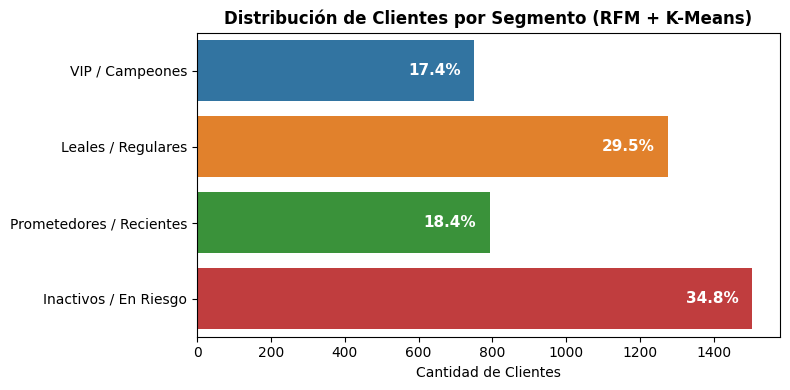

In [41]:
""" Visualización de distribución de Perfiles (Clientes por Segmento) """

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(8,4))
axes = sns.countplot(
    data=rfm,
    y="Cluster_Name",
    order=[
        "VIP / Campeones",
        "Leales / Regulares",
        "Prometedores / Recientes",
        "Inactivos / En Riesgo"
           ],
    hue="Cluster_Name"
)

axes.set_title("Distribución de Clientes por Segmento (RFM + K-Means)", fontsize=12, fontweight="bold")
axes.set_xlabel("Cantidad de Clientes")
axes.set_ylabel("")

# Agregar Porcentajes en las barras
total = len(rfm)
for p in axes.patches:
    percentage = f"{100 * p.get_width() / total:.1f}%"
    x = p.get_width() - 180
    y = p.get_y() + p.get_height() / 2
    axes.annotate(percentage, (x,y), va="center", fontsize=11, fontweight="bold", color="#ffffff")

plt.tight_layout()
plt.show()

In [42]:
""" Exportar csv actualizado """

rfm.to_csv(r"C:\Users\Highlightning\Documents\Ciencia de Datos\Proyectos\Clustering (Customer Segmentation & Persona Profiling)\.gitignore\data\processed\rfm_KMeans.csv", index=False)
print("¡Reporte 'Clientes por Segmento (RFM + K-Means)' en data/processed/rfm_KMeans.csv")

¡Reporte 'Clientes por Segmento (RFM + K-Means)' en data/processed/rfm_KMeans.csv
